# Détection d'anomalies avec un auto-encodeur (Fashion-MNIST)

Reprise du notebook 01 original sur un jeu de données plus difficile. Toujours la même idée :
entraîner un auto-encodeur uniquement sur des exemples "normaux", et se servir de l'erreur de
reconstruction pour repérer les anomalies.

Données : Fashion-MNIST (784 pixels, images 28x28), limité à deux classes visuellement très
proches — **T-shirt/top** (normal) et **Shirt** (anomalie) — la paire la plus confondue du
dataset. Contrairement au cancer du sein où la tumeur a une signature nette, ici l'"anomalie"
ressemble beaucoup au normal : c'est un cas plus réaliste et plus dur pour la détection
d'anomalies par reconstruction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report, f1_score, roc_auc_score, average_precision_score, recall_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

## Données

Fashion-MNIST a 10 classes ; je n'en garde que deux : `0` = T-shirt/top et `6` = Shirt (les
libellés OpenML d'origine). Je définis `0 = normal` (T-shirt/top) et `1 = anomalie` (Shirt),
directement dans le sens qui m'intéresse pour ce notebook — pas besoin d'inverser une
convention scikit-learn comme sur le cancer.

In [2]:
data = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all, y_all = data.data, data.target.astype(int)

CLASSES = {0: "T-shirt/top", 6: "Shirt"}
mask = np.isin(y_all, list(CLASSES))
X = X_all[mask]
y_raw = y_all[mask]
y = (y_raw == 6).astype(int)  # 0 = T-shirt/top (normal), 1 = Shirt (anomalie)

print("classes gardees:", CLASSES)
print("X:", X.shape)

classes gardees: {0: 'T-shirt/top', 6: 'Shirt'}
X: (14000, 784)


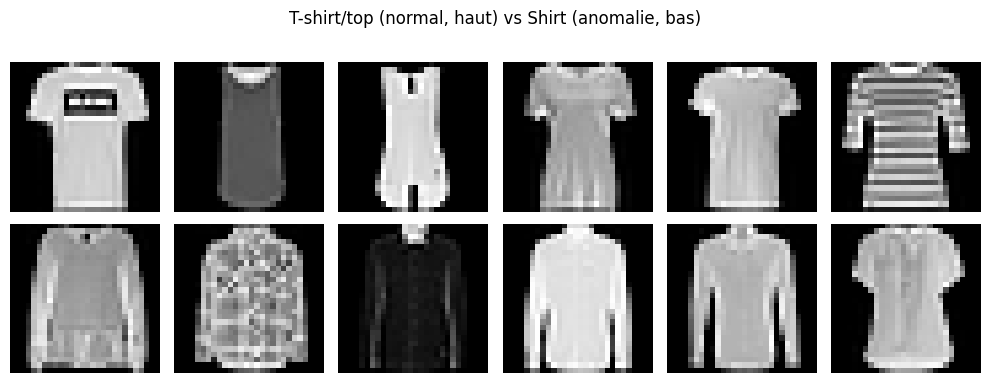

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for row, label in enumerate([0, 1]):
    idx = np.where(y == label)[0][:6]
    for col, i in enumerate(idx):
        axes[row, col].imshow(X[i].reshape(28, 28), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel("normal" if label == 0 else "anomalie")
fig.suptitle("T-shirt/top (normal, haut) vs Shirt (anomalie, bas)")
plt.tight_layout()
plt.show()

In [4]:
pd.Series(y).value_counts().rename({0: "normal (T-shirt/top)", 1: "anomalie (Shirt)"})

normal (T-shirt/top)    7000
anomalie (Shirt)        7000
Name: count, dtype: int64

## Préparation

Je n'entraîne que sur les "normaux" (T-shirt/top). Le test contient des T-shirt/top laissés de
côté + tous les Shirt.

In [5]:
X_sain = X[y == 0]
X_anomalies = X[y == 1]

X_train_sain, X_test_sain = train_test_split(X_sain, test_size=0.3, random_state=SEED)

X_test = np.vstack((X_test_sain, X_anomalies))
y_test = np.hstack([np.zeros(len(X_test_sain)), np.ones(len(X_anomalies))])

print("train (normal):", X_train_sain.shape)
print("test:", X_test.shape, "-", int(y_test.sum()), "anomalies")

train (normal): (4900, 784)
test: (9100, 784) - 7000 anomalies


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sain)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()
y_test_tensor = torch.from_numpy(y_test).long()

# batch_size monte a 128 (vs 64 sur le cancer) : 14 000 exemples ici contre 569,
# on garde un nombre de batches par epoch raisonnable
train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=128, shuffle=False)

## Le modèle

Même architecture que l'original, mais mise à l'échelle pour l'entrée : 784 pixels au lieu de
30 variables, donc des couches cachées plus larges (256 puis 64) pour laisser à l'encodeur de
quoi capturer une structure d'image bien plus riche. Latent toujours en dimension 2 pour
pouvoir le visualiser.

In [7]:
class Encodeur(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dim),
        )
    def forward(self, x):
        return self.net(x)

class Decodeur(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 784),
        )
    def forward(self, z):
        return self.net(z)

class AutoEncodeur(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

## Entraînement

20 0.4747


40 0.4441


60 0.4285


80 0.4025


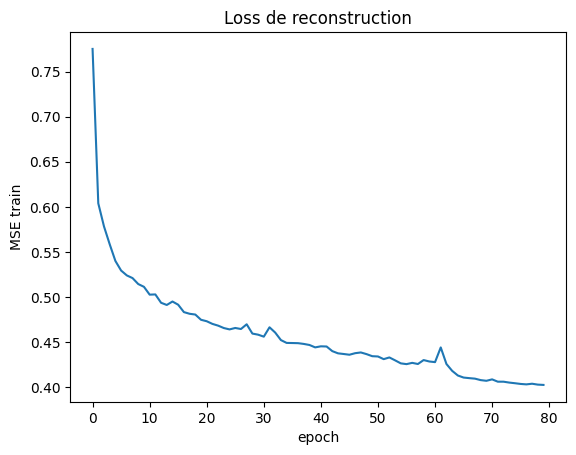

In [8]:
set_seed()
ae = AutoEncodeur(latent_dim=2)

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

losses = []
for epoch in range(80):
    ae.train()
    running = 0.0
    for (xb,) in train_loader:
        optimizer.zero_grad()
        out = ae(xb)
        loss = loss_fn(out, xb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    epoch_loss = running / len(train_loader.dataset)
    losses.append(epoch_loss)
    scheduler.step(epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(epoch + 1, round(epoch_loss, 4))

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("MSE train"); plt.title("Loss de reconstruction")
plt.savefig("figures/ae_loss.png", dpi=130, bbox_inches="tight")
plt.show()

## Erreurs de reconstruction

MSE par image sur le test. Ce que j'espère voir : des erreurs plus élevées côté Shirt
(l'anomalie) — mais comme les deux classes se ressemblent, l'écart devrait être bien moins net
que sur le cancer.

erreur moyenne normal   : 0.5181
erreur moyenne anomalies: 1.3974


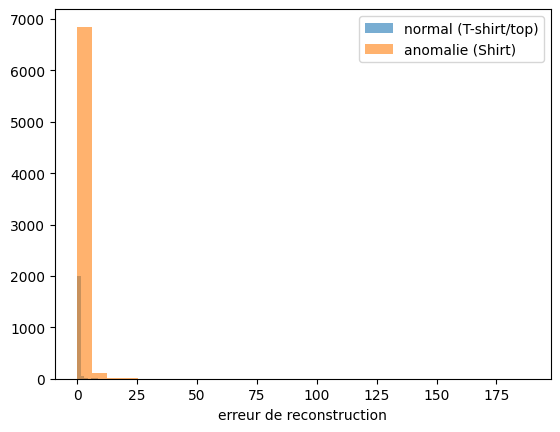

In [9]:
ae.eval()
errors = []
y_true = []
with torch.no_grad():
    for xb, yb in test_loader:
        out = ae(xb)
        mse = torch.mean((xb - out) ** 2, dim=1)
        errors.extend(mse.numpy())
        y_true.extend(yb.numpy())

errors = np.array(errors)
y_true = np.array(y_true)

print("erreur moyenne normal   :", round(errors[y_true == 0].mean(), 4))
print("erreur moyenne anomalies:", round(errors[y_true == 1].mean(), 4))

plt.hist(errors[y_true == 0], bins=30, alpha=0.6, label="normal (T-shirt/top)")
plt.hist(errors[y_true == 1], bins=30, alpha=0.6, label="anomalie (Shirt)")
plt.xlabel("erreur de reconstruction"); plt.legend()
plt.savefig("figures/reconstruction_hist.png", dpi=130, bbox_inches="tight")
plt.show()

## Espace latent

Comme le latent est en 2D, on peut le tracer directement.

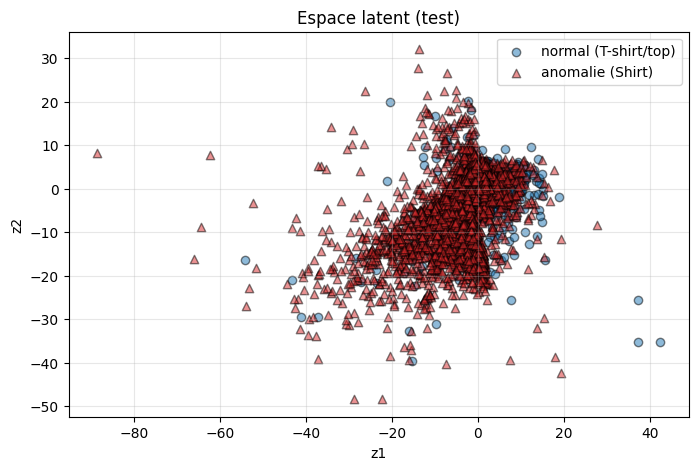

In [10]:
ae.eval()
zs, ys = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        zs.append(ae.encodeur(xb).numpy())
        ys.append(yb.numpy())
Z = np.vstack(zs)
Y = np.concatenate(ys)

plt.figure(figsize=(8, 5))
plt.scatter(Z[Y == 0, 0], Z[Y == 0, 1], c="tab:blue", alpha=0.5, edgecolors="k", label="normal (T-shirt/top)")
plt.scatter(Z[Y == 1, 0], Z[Y == 1, 1], c="tab:red", alpha=0.5, edgecolors="k", marker="^", label="anomalie (Shirt)")
plt.xlabel("z1"); plt.ylabel("z2"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Espace latent (test)")
plt.savefig("figures/latent_space.png", dpi=130, bbox_inches="tight")
plt.show()

## Choix du seuil

Le score continu (erreur de reconstruction) doit devenir une décision. Je teste deux façons de
fixer le seuil, et pour comparer honnêtement je coupe le test en deux : une moitié sert à régler
le seuil, l'autre sert de test final. Les deux méthodes sont jugées sur la même moitié.

- seuil non supervisé : 95e percentile des erreurs sur le train (que des "normaux")
- seuil calibré : celui qui maximise le F1 sur la moitié validation

In [11]:
errors_val, errors_test, y_val, y_test_final = train_test_split(
    errors, y_true, test_size=0.5, stratify=y_true, random_state=SEED)

In [12]:
# seuil non supervise : percentile sur les erreurs du train
train_errors = []
with torch.no_grad():
    for (xb,) in train_loader:
        out = ae(xb)
        train_errors.extend(torch.mean((xb - out) ** 2, dim=1).numpy())
train_errors = np.array(train_errors)

seuil_stat = np.percentile(train_errors, 95)
pred_stat = (errors_test >= seuil_stat).astype(int)

In [13]:
# seuil calibre par recherche sur la moitie validation
grid = np.linspace(errors_val.min(), errors_val.max(), 500)
best_f1, seuil_grid = -1, grid[0]
for t in grid:
    f = f1_score(y_val, (errors_val >= t).astype(int), zero_division=0)
    if f > best_f1:
        best_f1, seuil_grid = f, t

pred_grid = (errors_test >= seuil_grid).astype(int)

## Comparaison

ROC-AUC et PR-AUC ne dépendent pas du seuil.

In [14]:
print("ROC-AUC:", round(roc_auc_score(y_test_final, errors_test), 3))
print("PR-AUC :", round(average_precision_score(y_test_final, errors_test), 3))
print()

print("seuil non supervise (95e perc.) =", round(seuil_stat, 3))
print("F1:", round(f1_score(y_test_final, pred_stat), 3),
      "| rappel anomalies:", round(recall_score(y_test_final, pred_stat), 3))
print(classification_report(y_test_final, pred_stat, target_names=["normal", "anomalie"]))

print("seuil calibre (grid F1) =", round(seuil_grid, 3), "(F1 val =", round(best_f1, 3), ")")
print("F1:", round(f1_score(y_test_final, pred_grid), 3),
      "| rappel anomalies:", round(recall_score(y_test_final, pred_grid), 3))
print(classification_report(y_test_final, pred_grid, target_names=["normal", "anomalie"]))

ROC-AUC: 0.792
PR-AUC : 0.917

seuil non supervise (95e perc.) = 1.148
F1: 0.552 | rappel anomalies: 0.389
              precision    recall  f1-score   support

      normal       0.31      0.94      0.47      1050
    anomalie       0.95      0.39      0.55      3500

    accuracy                           0.52      4550
   macro avg       0.63      0.66      0.51      4550
weighted avg       0.81      0.52      0.53      4550

seuil calibre (grid F1) = 0.035 (F1 val = 0.87 )
F1: 0.869 | rappel anomalies: 1.0
              precision    recall  f1-score   support

      normal       0.00      0.00      0.00      1050
    anomalie       0.77      1.00      0.87      3500

    accuracy                           0.77      4550
   macro avg       0.38      0.50      0.43      4550
weighted avg       0.59      0.77      0.67      4550



## Bilan

Sur cette paire difficile, l'erreur de reconstruction sépare bien moins nettement le normal de
l'anomalie que sur le cancer : ROC-AUC 0,792 (vs ~0,96), erreur moyenne 0,52 pour le normal
contre 1,40 pour l'anomalie (l'écart existe, mais les distributions se chevauchent beaucoup plus).
C'est cohérent avec le choix du dataset : T-shirt/top et Shirt sont visuellement proches, donc
plus dures à distinguer par reconstruction qu'un tissu sain d'une tumeur.

Un résultat inattendu : le seuil "calibré" (qui maximise le F1 sur la moitié validation) tombe à
0,035, un seuil quasiment nul qui revient à classer *toute* image comme anomalie (rappel = 1,0,
précision normale = 0). Ça marche numériquement parce que le test est très déséquilibré (77 %
d'anomalies, puisque toutes les Shirt du dataset finissent en test alors que les T-shirt/top sont
sous-échantillonnés) : prédire "anomalie" pour tout le monde maximise déjà le F1 sur la classe
majoritaire. Le seuil non supervisé (95e percentile) évite ce piège en donnant un vrai compromis
(F1 0,552, rappel anomalies 0,389) mais reste modeste. Contrairement au notebook original, la
calibration par F1 n'est donc pas automatiquement la meilleure option : sur un déséquilibre fort,
elle peut dégénérer vers une règle triviale. La suite (notebook 02) réutilise le même encodeur,
mais comme pré-entraînement pour classer.